## Figure 2 of Phynteny Transformer Manuscript

In [1]:
import os
os.chdir('/home/grig0076/GitHubs/Phynteny_transformer_15012025/Phynteny_transformer/')
import pickle
from src import format_data
from src import model_onehot 
from src import predictor
import pandas as pd
import seaborn  as sns
import numpy as np 
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.pyplot as plt
import pickle
import torch
import glob
from torch.utils.data import DataLoader
import torch.nn.functional as F
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

/home/grig0076/miniconda3/envs/phynteny_transformer2/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# read in plots of how well the model trained 
metrics = pd.read_csv('/home/grig0076/scratch/Phynteny_transformer/models/2025-05-15_lambda/2025-05-07_16_0.15_circular_1e-5_0.1_512_8_2_100_10_0.0_0.6_false_True_true_true_1.0_0.7_sinusoidal/metrics.csv')

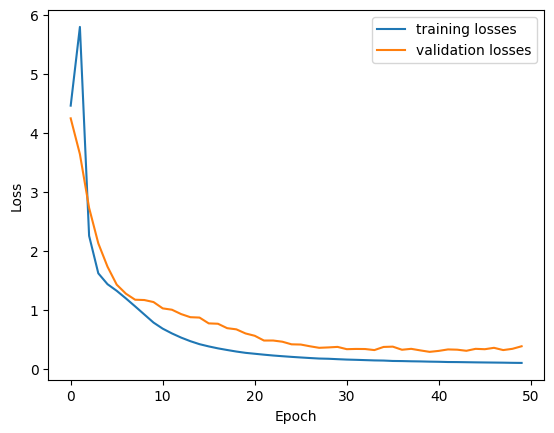

In [22]:
sns.lineplot(data=metrics[['training losses', 'validation losses']].stack(future_stack=True).reset_index(), 
             x = 'level_0', y  = 0 , hue = 'level_1')
plt.xlabel('Epoch')
plt.ylabel('Loss')
# Set legend title
plt.legend(title='')
plt.show()

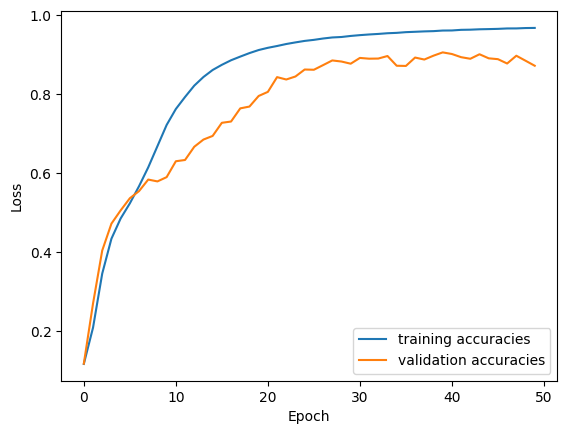

In [23]:
sns.lineplot(data=metrics[['training accuracies', 'validation accuracies']].stack(future_stack=True).reset_index(), 
             x = 'level_0', y  = 0 , hue = 'level_1')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(title='')
plt.show()

In [126]:
colors1 = ['#f8f8ff', '#DDDDDD', '#CC6677','#DDCC77', '#332288',  '#117733', '#88CCEE',
                    '#882255', '#44AA99',  '#AA4499', '#999933'] # can be accessed from  


In [4]:
phrog_integer = pickle.load(
        open(
            "/home/grig0076/GitHubs/Phynteny/phynteny_utils/phrog_annotation_info/integer_category.pkl",
            "rb",
        )
    )

In [13]:
colors2= ['#7f3c8d', '#119c73', '#3969ac', '#f2b701', '#e73f74', '#90bb35', '#e68310', '#1bafbf', '#e3493e', '#a5aa99']

# 1. Visualise Gene Order

In [2]:
phrogs = pd.read_csv(
        "/home/grig0076/GitHubs/Phynteny/phynteny_utils/phrog_annotation_info/phrog_annot_v4.tsv",
        sep="\t",
    )
category_dict = dict(zip(phrogs["phrog"], phrogs["category"])) 
    
phrog_integer = pickle.load(
        open(
            "/home/grig0076/GitHubs/Phynteny/phynteny_utils/phrog_annotation_info/integer_category.pkl",
            "rb",
        )
    )
phrog_integer = dict(
        zip(
            [i - 1 for i in list(phrog_integer.keys())],
            [i for i in list(phrog_integer.values())],
        )
    )  # shuffling the keys down by one
phrog_integer_reverse = dict(
        zip(list(phrog_integer.values()), list(phrog_integer.keys()))
    )
phrog_integer_reverse["unknown function"] = -1
phrog_integer_category = dict(
        zip(
            [str(k) for k in list(category_dict.keys())],
            [phrog_integer_reverse.get(k) for k in list(category_dict.values())],
        )
    )

In [ ]:
data = dict() 
files = glob.glob('/home/grig0076/scratch/Phynteny_transformer/PhageScope/filtered_phage_scope.fasta.split/*/pharokka.gbk')

for file in files: 
    print(file)
    d = format_data.fetch_data(file, 2, phrog_integer_category, 2000)
    data.update(d) 

In [350]:
#subset_keys = [d for d in list(set(data.keys()).intersection(set(subset_ids)))]
subset_keys = list(data.keys())
subset_values = [data.get(d) for d in subset_keys]
subset_data = dict(zip(subset_keys, subset_values))

In [351]:
keys = list(subset_data.keys())
lengths = [subset_data.get(k).get('length') for k in keys]
keys_length_filter = [k for k in keys if subset_data.get(k).get('length') <=60000 ]
keys_length_filter_integrase = [k for k in keys_length_filter if 0 in list(subset_data.get(k).get('categories'))]
keys_filter_categories_present = [k for k in keys_length_filter_integrase if 0 in list(subset_data.get(k).get('categories')) and 2 in list(data.get(k).get('categories')) and 7 in list(data.get(k).get('categories')) and 3 in list(data.get(k).get('categories'))]

In [353]:
len(keys_filter_categories_present)

26091

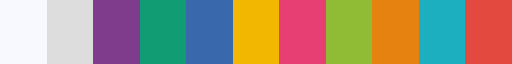

In [354]:
ListedColormap( ['#f8f8ff', '#DDDDDD'] + colors2[:len(np.unique(plot_arr))][:-1])
#colors  = ['#f8f8ff', '#DDDDDD', '#167288', '#8cdaec', '#b45248', '#d48c84', '#a89a49', '#d6cfa2','#643c6a' , '#3cb464','#9bddb1', '#836394']

#### remake the figure above so that it takes phages with a head and packaging gene, integration gene and tail gene then make the tail come after the head with recircularising 

In [356]:
#plot_arr = np.zeros((len(keys_length_filter_integrase), 600))
plot_arr = np.zeros((len(keys_filter_categories_present), 600))
plot_arr = plot_arr - 2  # Default background color

# Go through and color accordingly
for i, k in enumerate(keys_filter_categories_present):
#for i, k in enumerate(keys_length_filter_integrase): 
    # Get the categories and their positions
    categories = data.get(k).get('categories')
    categories = [-1 if x is None else x for x in categories]
    positions = data.get(k).get('position')

    # Ensure start <= stop for each segment
    positions = [(min(start, stop), max(start, stop)) for start, stop in positions]

    # Check the positions of the first occurrences of 2 and 7
    if 2 in categories and 7 in categories:
        first_2 = categories.index(2)
        first_7 = categories.index(7)

        if first_7 < first_2:  # If 7 appears before 2, reverse everything
            
            max_pos = max(stop for _, stop in positions)  # Get the largest position

            # Reverse categories
            categories.reverse()
            
            positions = [(max_pos - stop, max_pos - start) for start, stop in reversed(positions)] 

    # Find the first occurrence of category 0 and recircularize
    if 0 in categories:
        zero_idx = categories.index(0)  # First occurrence of 0
        categories = categories[zero_idx:] + categories[:zero_idx]
        positions = positions[zero_idx:] + positions[:zero_idx]
    
        # Reindex positions: start from 0 while preserving segment lengths and gaps
        new_positions = []
        offset = 0  # New start position

        for idx, (start, stop) in enumerate(positions):
            length = stop - start  # Keep the segment length the same

            # If not the first segment, preserve the original gap
            if idx > 0:
                prev_stop = new_positions[-1][1]
                gap = max(0, start - positions[idx - 1][1])  # Ensure gaps are non-negative
                offset = prev_stop + gap  # Move forward while keeping gaps

            # Assign new start and stop
            new_start = offset
            new_stop = new_start + length
            new_positions.append((new_start, new_stop))

            # Update offset for the next segment
            offset = new_stop

        positions = new_positions  # Replace with updated positions

    # Assign to plot_arr
    for j, c in enumerate(categories):
        start = int(positions[j][0] / 100)
        stop = int(positions[j][1] / 100)
        plot_arr[i][start:stop] = c

plot_df = pd.DataFrame(plot_arr)

/home/grig0076/miniconda3/envs/phynteny_transformer2/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


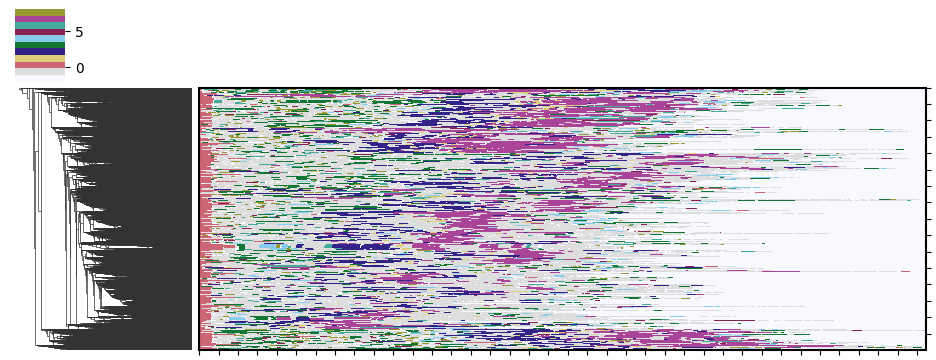

In [357]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as patches


filtered_df= plot_df

# Create the heatmap
#colors1 = ['#f8f8ff', '#DDDDDD', '#CC6677','#DDCC77', '#332288',  '#117733', '#88CCEE',
#                    '#882255', '#44AA99',  '#AA4499', '#999933'] # can be accessed from  

colors1 = ['#f8f8ff', '#DDDDDD','#CC6677', '#DDCC77', '#332288', '#117733', '#88CCEE',
           '#882255', '#44AA99', '#AA4499', '#999933']
cmap = ListedColormap(colors1)
g = sns.clustermap(filtered_df, cmap=cmap, annot=False, cbar=True, col_cluster=False, figsize=(10, 4))

# Hide x and y tick labels
g.ax_heatmap.set_xticklabels([])
g.ax_heatmap.set_yticklabels([])

# Get heatmap position and dimensions
x0, y0, width, height = g.ax_heatmap.get_position().bounds

# Add an outline (black border) around the heatmap
rect = patches.Rectangle(
    (x0, y0), width, height, linewidth=1.5, edgecolor="black", facecolor="none", transform=g.fig.transFigure, clip_on=False
)
g.fig.patches.append(rect)

# Save the figure
g.savefig("/home/grig0076/GitHubs/Phynteny_transformer/notebooks/manuscript_figures/synteny_fig.png", dpi=300, bbox_inches="tight")

plt.show()

# 2. ROC Curve/Precision Recall Curve

Make ROC curves for the phold annotations in the phold annoated data 

## ROC curves based on phold annotations in the PhageScope dataset

### Select data for the phold validation set 

### Visualise the computed ROC curves
#### ROC curve on the complete model with phold proteins

In [11]:
average_precision = pickle.load(open('/home/grig0076/scratch/Phynteny_transformer/roc_curve/roc_data_2025-4-24-2layers-lstm_0.7proteindropout/average_precision_dict.pkl', 'rb'))
fpr_dict = pickle.load(open('/home/grig0076/scratch/Phynteny_transformer/roc_curve/roc_data_2025-4-24-2layers-lstm_0.7proteindropout/fpr_dict.pkl', 'rb'))
mean_avg_precision = pickle.load(open('/home/grig0076/scratch/Phynteny_transformer/roc_curve/roc_data_2025-4-24-2layers-lstm_0.7proteindropout/mean_avg_precision_dict.pkl', 'rb'))
mean_precision = pickle.load(open('/home/grig0076/scratch/Phynteny_transformer/roc_curve/roc_data_2025-4-24-2layers-lstm_0.7proteindropout/mean_precision_dict.pkl', 'rb'))
precision_dict = pickle.load(open('/home/grig0076/scratch/Phynteny_transformer/roc_curve/roc_data_2025-4-24-2layers-lstm_0.7proteindropout/precision_dict.pkl', 'rb'))
recall_dict = pickle.load(open('/home/grig0076/scratch/Phynteny_transformer/roc_curve/roc_data_2025-4-24-2layers-lstm_0.7proteindropout/recall_dict.pkl', 'rb'))
roc_auc_dict = pickle.load(open('/home/grig0076/scratch/Phynteny_transformer/roc_curve/roc_data_2025-4-24-2layers-lstm_0.7proteindropout/roc_auc_dict.pkl', 'rb'))
std_precision_dict = pickle.load(open('/home/grig0076/scratch/Phynteny_transformer/roc_curve/roc_data_2025-4-24-2layers-lstm_0.7proteindropout/std_precision_dict.pkl', 'rb'))
average_precision_dict = pickle.load(open('/home/grig0076/scratch/Phynteny_transformer/roc_curve/roc_data_2025-4-24-2layers-lstm_0.7proteindropout/average_precision_dict.pkl', 'rb'))
std_tpr_dict = pickle.load(open('/home/grig0076/scratch/Phynteny_transformer/roc_curve/roc_data_2025-4-24-2layers-lstm_0.7proteindropout/std_tpr_dict.pkl', 'rb'))
tpr_dict = pickle.load(open('/home/grig0076/scratch/Phynteny_transformer/roc_curve/roc_data_2025-4-24-2layers-lstm_0.7proteindropout/tpr_dict.pkl', 'rb'))

In [46]:
average_precision = pickle.load(open('/home/grig0076/scratch/Phynteny_transformer/models/2025-05-15_lambda/2025-05-07_16_0.15_circular_1e-5_0.1_512_8_2_100_10_0.0_0.6_false_True_true_true_1.0_0.7_sinusoidal.roc/average_precision_dict.pkl', 'rb'))
fpr_dict = pickle.load(open('/home/grig0076/scratch/Phynteny_transformer/models/2025-05-15_lambda/2025-05-07_16_0.15_circular_1e-5_0.1_512_8_2_100_10_0.0_0.6_false_True_true_true_1.0_0.7_sinusoidal.roc/fpr_dict.pkl', 'rb'))
mean_avg_precision = pickle.load(open('/home/grig0076/scratch/Phynteny_transformer/models/2025-05-15_lambda/2025-05-07_16_0.15_circular_1e-5_0.1_512_8_2_100_10_0.0_0.6_false_True_true_true_1.0_0.7_sinusoidal.roc/mean_avg_precision_dict.pkl', 'rb'))
mean_precision = pickle.load(open('/home/grig0076/scratch/Phynteny_transformer/models/2025-05-15_lambda/2025-05-07_16_0.15_circular_1e-5_0.1_512_8_2_100_10_0.0_0.6_false_True_true_true_1.0_0.7_sinusoidal.roc/mean_precision_dict.pkl', 'rb'))
precision_dict = pickle.load(open('/home/grig0076/scratch/Phynteny_transformer/models/2025-05-15_lambda/2025-05-07_16_0.15_circular_1e-5_0.1_512_8_2_100_10_0.0_0.6_false_True_true_true_1.0_0.7_sinusoidal.roc/precision_dict.pkl', 'rb'))
recall_dict = pickle.load(open('/home/grig0076/scratch/Phynteny_transformer/models/2025-05-15_lambda/2025-05-07_16_0.15_circular_1e-5_0.1_512_8_2_100_10_0.0_0.6_false_True_true_true_1.0_0.7_sinusoidal.roc/recall_dict.pkl', 'rb'))
roc_auc_dict = pickle.load(open('/home/grig0076/scratch/Phynteny_transformer/models/2025-05-15_lambda/2025-05-07_16_0.15_circular_1e-5_0.1_512_8_2_100_10_0.0_0.6_false_True_true_true_1.0_0.7_sinusoidal.roc/roc_auc_dict.pkl', 'rb'))
std_precision_dict = pickle.load(open('/home/grig0076/scratch/Phynteny_transformer/models/2025-05-15_lambda/2025-05-07_16_0.15_circular_1e-5_0.1_512_8_2_100_10_0.0_0.6_false_True_true_true_1.0_0.7_sinusoidal.roc/std_precision_dict.pkl', 'rb'))
average_precision_dict = pickle.load(open('/home/grig0076/scratch/Phynteny_transformer/models/2025-05-15_lambda/2025-05-07_16_0.15_circular_1e-5_0.1_512_8_2_100_10_0.0_0.6_false_True_true_true_1.0_0.7_sinusoidal.roc/average_precision_dict.pkl', 'rb'))
std_tpr_dict = pickle.load(open('/home/grig0076/scratch/Phynteny_transformer/models/2025-05-15_lambda/2025-05-07_16_0.15_circular_1e-5_0.1_512_8_2_100_10_0.0_0.6_false_True_true_true_1.0_0.7_sinusoidal.roc/std_tpr_dict.pkl', 'rb'))
tpr_dict = pickle.load(open('/home/grig0076/scratch/Phynteny_transformer/models/2025-05-15_lambda/2025-05-07_16_0.15_circular_1e-5_0.1_512_8_2_100_10_0.0_0.6_false_True_true_true_1.0_0.7_sinusoidal.roc/tpr_dict.pkl', 'rb'))

In [48]:
#roc_auc_dict
num_classes=9

integration and excision
connector
head and packaging
DNA, RNA and nucleotide metabolism
lysis
moron, auxiliary metabolic gene and host takeover
other
tail
transcription regulation


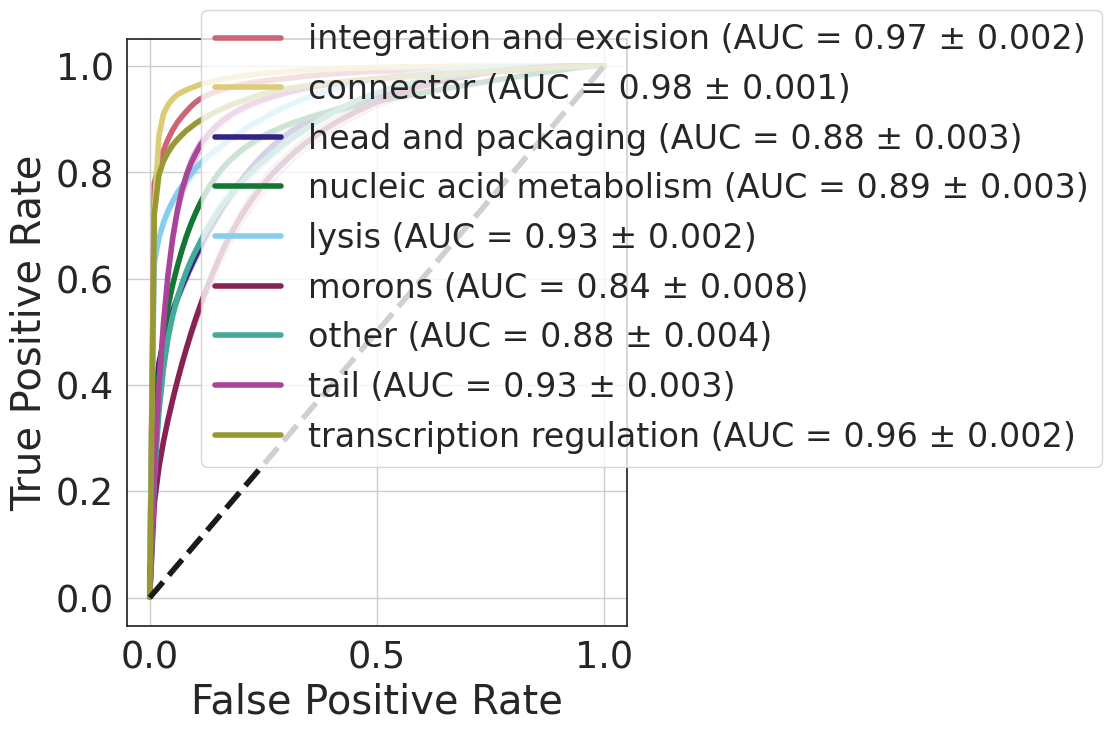

In [89]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Setup
phrog_categories = [f"{phrog_integer.get(i)}" for i in range(num_classes)]  # Replace with actual category names
sns.set(style='white', font_scale=2.4)

# Category name mapping and palette
name_dict = {
    'integration and excision': 'integration and excision',
    'connector': 'connector',
    'head and packaging': 'head and packaging',
    'DNA, RNA and nucleotide metabolism': 'nucleic acid metabolism',
    'lysis': 'lysis',
    'moron, auxiliary metabolic gene and host takeover': 'morons',
    'other': 'other',
    'tail': 'tail',
    'transcription regulation': 'transcription regulation'
}

base_order = [
    'integration and excision',
    'connector',
    'head and packaging',
    'nucleic acid metabolism',
    'lysis',
    'morons',
    'other',
    'tail',
    'transcription regulation'
]

colors1 = ['#CC6677', '#DDCC77', '#332288', '#117733', '#88CCEE',
           '#882255', '#44AA99', '#AA4499', '#999933']
palette = {label: color for label, color in zip(base_order, colors1)}

# Generate mean ROC curve
mean_fpr = np.linspace(0, 1, 100)
mean_tpr_dict = {}
mean_auc_dict = {}

std_auc = [np.std(i) for i in roc_auc_dict.values()]  # Compute std AUC once

plt.figure(figsize=(12, 8))

for i in range(num_classes):
    category_name = phrog_categories[i]
    print(category_name)
    mapped_name = name_dict.get(category_name, category_name)
    color = palette.get(mapped_name, '#000000')  # fallback to black if category not found

    mean_tpr = np.mean(fpr_dict[i], axis=0)
    std_tpr = np.std(fpr_dict[i], axis=0)
    mean_auc = np.mean(roc_auc_dict[i])

    label = f"{mapped_name} (AUC = {mean_auc:.2f} ± {std_auc[i]:.3f})"
    plt.plot(mean_fpr, mean_tpr, label=label, color=color, linewidth=4)
    plt.fill_between(mean_fpr, mean_tpr - std_tpr, mean_tpr + std_tpr, alpha=0.2, color=color)

# Plot diagonal line
plt.plot([0, 1], [0, 1], "k--", linewidth=4)

# Labels and layout
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="upper center", bbox_to_anchor=(1.05, 1.05), fontsize="small", borderaxespad=0)
plt.grid()
plt.tight_layout()
plt.savefig('/home/grig0076/GitHubs/Phynteny_transformer/ROC.png')
plt.show()


## Precision Recall Curve as well 

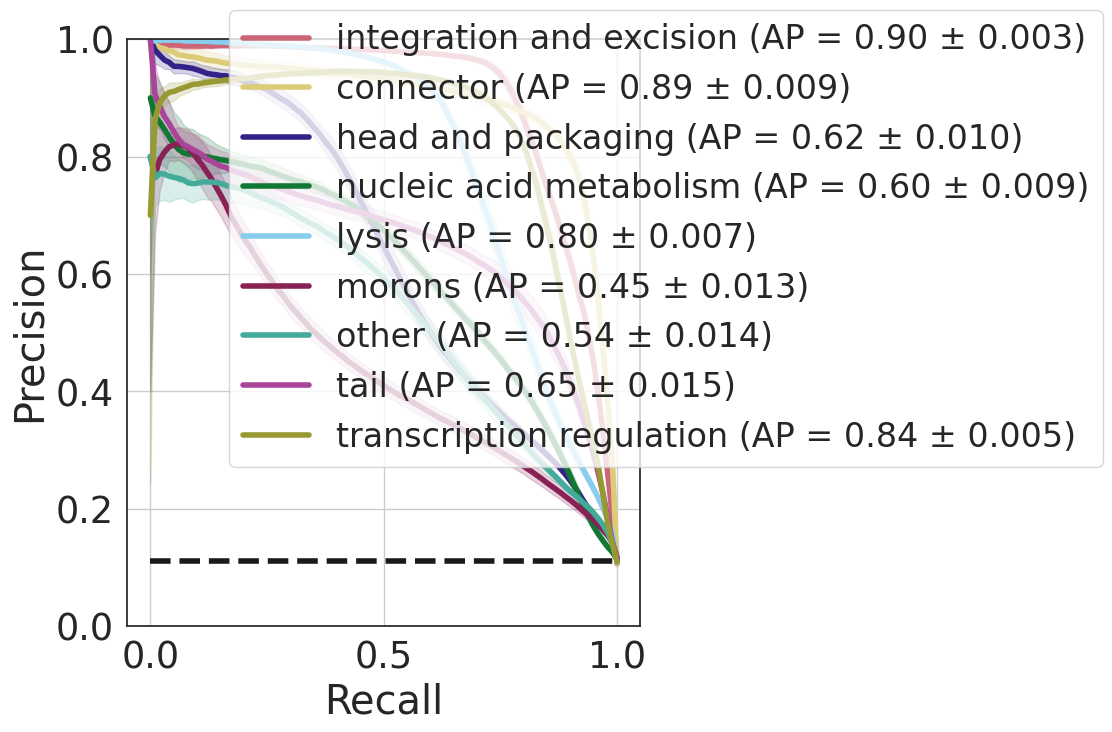

In [86]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Setup
sns.set(style='white', font_scale=2.4)
num_classes = 9

# Define PHROG category names
phrog_categories = [f"{phrog_integer.get(i)}" for i in range(num_classes)]

# Category name mapping
name_dict = {
    'integration and excision': 'integration and excision',
    'connector': 'connector',
    'head and packaging': 'head and packaging',
    'DNA, RNA and nucleotide metabolism': 'nucleic acid metabolism',
    'lysis': 'lysis',
    'moron, auxiliary metabolic gene and host takeover': 'morons',
    'other': 'other',
    'tail': 'tail',
    'transcription regulation': 'transcription regulation'
}

# Ordered categories and color palette
base_order = [
    'integration and excision',
    'connector',
    'head and packaging',
    'nucleic acid metabolism',
    'lysis',
    'morons',
    'other',
    'tail',
    'transcription regulation'
]

colors1 = ['#CC6677', '#DDCC77', '#332288', '#117733', '#88CCEE',
           '#882255', '#44AA99', '#AA4499', '#999933']
palette = {label: color for label, color in zip(base_order, colors1)}

# Prepare average precision-recall curves
mean_recall = np.linspace(0, 1, 100)
mean_precision_dict = {}
mean_ap_dict = {}
std_precision_dict = [np.std(i) for i in average_precision_dict.values()]

plt.figure(figsize=(12, 8))

for i in range(num_classes):
    category_name = phrog_categories[i]
    mapped_name = name_dict.get(category_name, category_name)
    color = palette.get(mapped_name, '#000000')

    mean_precision = np.mean(precision_dict[i], axis=0)
    std_precision = np.std(precision_dict[i], axis=0)
    mean_ap = np.mean(average_precision_dict[i])

    label = f"{mapped_name} (AP = {mean_ap:.2f} ± {std_precision_dict[i]:.3f})"
    plt.plot(mean_recall, mean_precision, label=label, color=color, linewidth=4)
    plt.fill_between(mean_recall,
                     mean_precision - std_precision,
                     mean_precision + std_precision,
                     alpha=0.2,
                     color=color)

# Plot random baseline
random_classifier_ap = 1 / num_classes
plt.plot([0, 1], [random_classifier_ap, random_classifier_ap], "k--", linewidth=4)

# Axis labels and legend
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.ylim((0, 1))
plt.legend(loc="upper center", bbox_to_anchor=(1.05, 1.05), fontsize="small", borderaxespad=0)
plt.grid()
plt.tight_layout()
plt.savefig('/home/grig0076/GitHubs/Phynteny_transformer/PR.png')
plt.show()


In [27]:
average_precision = pickle.load(open('/home/grig0076/scratch/Phynteny_transformer/roc_curve/roc_data_2025-4-24-0layers-nolstm_0.7proteindropout/average_precision_dict.pkl', 'rb'))
fpr_dict = pickle.load(open('/home/grig0076/scratch/Phynteny_transformer/roc_curve/roc_data_2025-4-24-0layers-nolstm_0.7proteindropout/fpr_dict.pkl', 'rb'))
mean_avg_precision = pickle.load(open('/home/grig0076/scratch/Phynteny_transformer/roc_curve/roc_data_2025-4-24-0layers-nolstm_0.7proteindropout/mean_avg_precision_dict.pkl', 'rb'))
mean_precision = pickle.load(open('/home/grig0076/scratch/Phynteny_transformer/roc_curve/roc_data_2025-4-24-0layers-nolstm_0.7proteindropout/mean_precision_dict.pkl', 'rb'))
precision_dict = pickle.load(open('/home/grig0076/scratch/Phynteny_transformer/roc_curve/roc_data_2025-4-24-0layers-nolstm_0.7proteindropout/precision_dict.pkl', 'rb'))
recall_dict = pickle.load(open('/home/grig0076/scratch/Phynteny_transformer/roc_curve/roc_data_2025-4-24-0layers-nolstm_0.7proteindropout/recall_dict.pkl', 'rb'))
roc_auc_dict = pickle.load(open('/home/grig0076/scratch/Phynteny_transformer/roc_curve/roc_data_2025-4-24-0layers-nolstm_0.7proteindropout/roc_auc_dict.pkl', 'rb'))
std_precision_dict = pickle.load(open('/home/grig0076/scratch/Phynteny_transformer/roc_curve/roc_data_2025-4-24-0layers-nolstm_0.7proteindropout/std_precision_dict.pkl', 'rb'))
average_precision_dict = pickle.load(open('/home/grig0076/scratch/Phynteny_transformer/roc_curve/roc_data_2025-4-24-0layers-nolstm_0.7proteindropout/average_precision_dict.pkl', 'rb'))
std_tpr_dict = pickle.load(open('/home/grig0076/scratch/Phynteny_transformer/roc_curve/roc_data_2025-4-24-0layers-nolstm_0.7proteindropout/std_tpr_dict.pkl', 'rb'))
tpr_dict = pickle.load(open('/home/grig0076/scratch/Phynteny_transformer/roc_curve/roc_data_2025-4-24-0layers-nolstm_0.7proteindropout/tpr_dict.pkl', 'rb'))

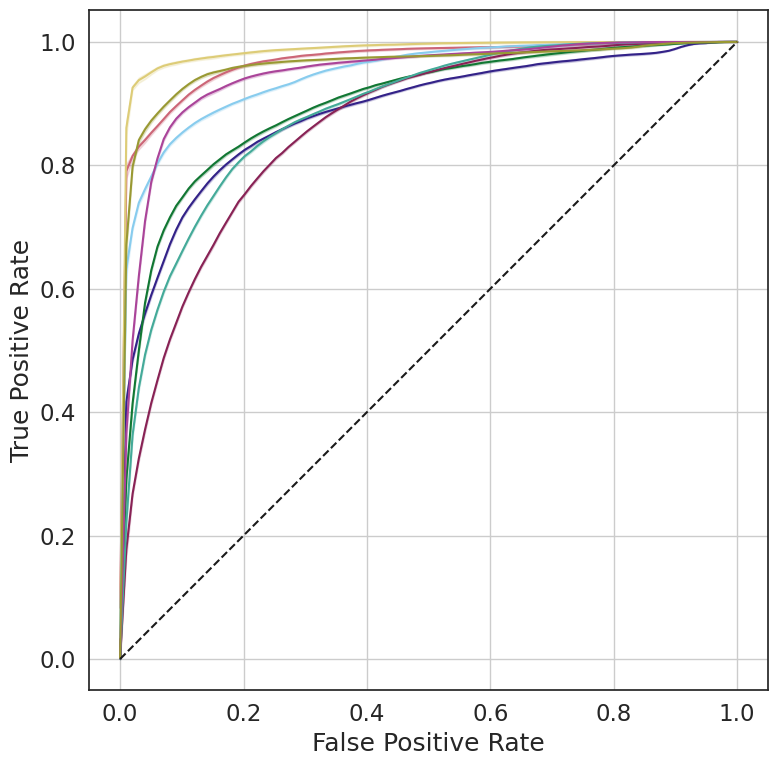

In [28]:
phrog_categories = [f"{phrog_integer.get(i+1)}" for i in range(num_classes)]  # Replace with actual category names
sns.set(style = 'white', font_scale=1.5)

# Average ROC curves and AUCs across folds
mean_fpr = np.linspace(0, 1, 100)
mean_tpr_dict = {}
mean_auc_dict = {}

num_classes=9

for i in range(num_classes):
    mean_tpr_dict[i] = np.mean(fpr_dict[i], axis=0)
    std_tpr = np.std(fpr_dict[i], axis=0)
    mean_auc_dict[i] = np.mean(roc_auc_dict[i])

# Plot average ROC curves with confidence intervals
plt.figure(figsize=(15, 8))

# get the auc for the curve 
std_auc = [np.std(i) for i in roc_auc_dict.values()] 

for i in range(num_classes):
    label = f"{phrog_categories[i]} (AUC = {mean_auc_dict[i]:.2f} ± {std_auc[i]:.3f})"
    plt.plot(mean_fpr, mean_tpr_dict[i], label=label, color=colors1[2:][i])
    plt.fill_between(mean_fpr,
                     mean_tpr_dict[i] - std_tpr,
                     mean_tpr_dict[i] + std_tpr,
                     alpha=0.2,
                     color=colors1[2:][i])

# Plot diagonal line for random guessing
plt.plot([0, 1], [0, 1], "k--")

# Set square aspect ratio
plt.gca().set_aspect("equal", adjustable="box")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate") 
#plt.legend(loc="upper center", bbox_to_anchor=(1.05, 1.05), fontsize="small", borderaxespad=0) # toggle legend for making a plot of this 
plt.grid()
plt.tight_layout()
plt.show()

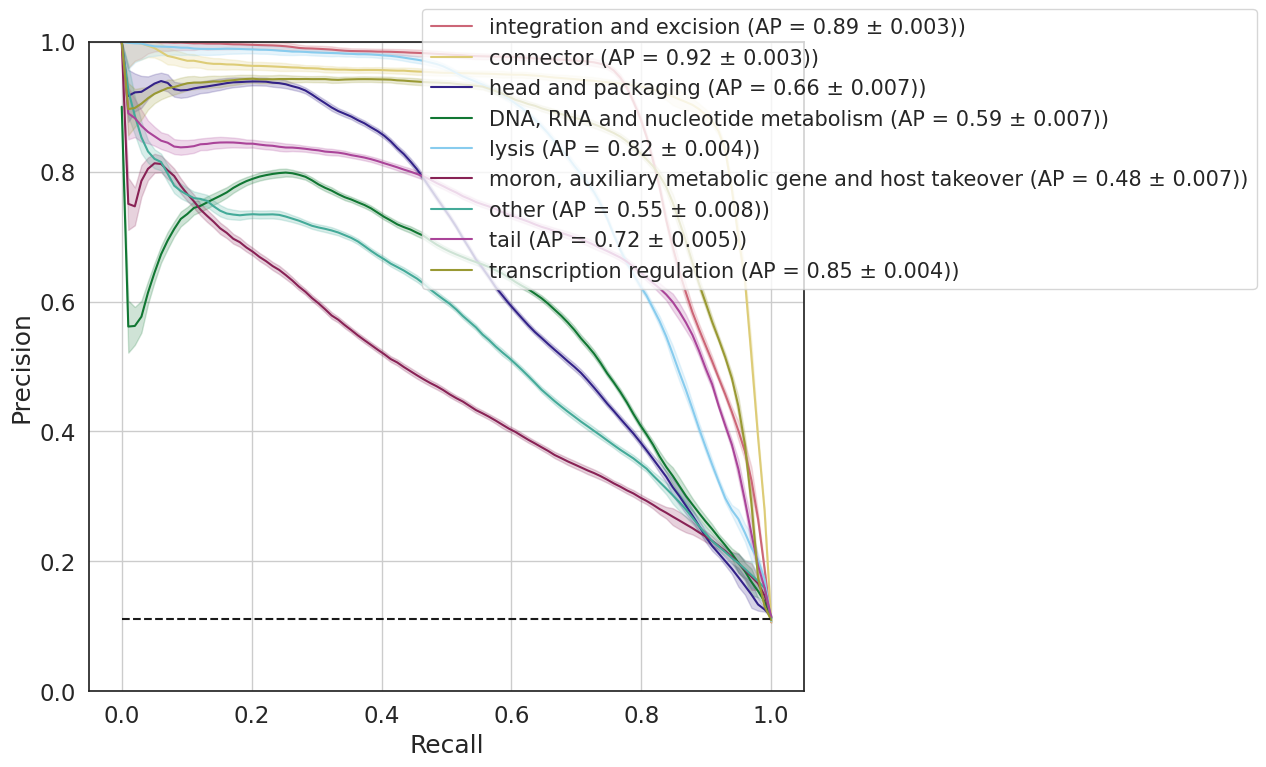

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define PHROG categories
phrog_categories = [f"{phrog_integer.get(i+1)}" for i in range(num_classes)]  # Replace with actual category names
sns.set(style='white', font_scale=1.5)

# Average Precision-Recall curves across folds
mean_recall = np.linspace(0, 1, 100)
mean_precision_dict = {}
mean_ap_dict = {}

num_classes = 9  # Adjust accordingly

for i in range(num_classes):
    mean_precision_dict[i] = np.mean(precision_dict[i], axis=0)
    std_precision = np.std(precision_dict[i], axis=0)
    mean_ap_dict[i] = np.mean(average_precision_dict[i])

# Plot average Precision-Recall curves with confidence intervals
plt.figure(figsize=(15, 8))

# get the auc for the curve 
std_precision_dict = [np.std(i) for i in average_precision_dict.values()] 


for i in range(num_classes):
    label = f"{phrog_categories[i]} (AP = {mean_ap_dict[i]:.2f} ± {std_precision_dict[i]:.3f}))"
    plt.plot(mean_recall, mean_precision_dict[i], label=label, color=colors1[2:][i])
    plt.fill_between(mean_recall,
                     mean_precision_dict[i] - std_precision,
                     mean_precision_dict[i] + std_precision,
                     alpha=0.2,
                     color=colors1[2:][i])

# Plot baseline (random classifier)
random_classifier_ap = 1 / num_classes  # Expected AP for a random classifier
plt.plot([0, 1], [random_classifier_ap, random_classifier_ap], "k--")

# Set square aspect ratio
plt.gca().set_aspect("equal", adjustable="box")

plt.xlabel("Recall")
plt.ylabel("Precision") 
plt.ylim((0,1))
plt.legend(loc="upper center", bbox_to_anchor=(1.05, 1.05), fontsize="small", borderaxespad=0)
plt.grid()
plt.tight_layout()
plt.show()

# 4. Visualisaing Attention Mechanism - what categories are attended too 


In [448]:
attention_matrices = pickle.load(open('/home/grig0076/scratch/Phynteny_transformer/inphared_test_attention/attention_weights/AB823818_attention_weights.pkl', 'rb'))

In [436]:
corresponding_categories = pd.read_csv('/home/grig0076/scratch/Phynteny_transformer/inphared_test_attention/phynteny.tsv', sep='\t')

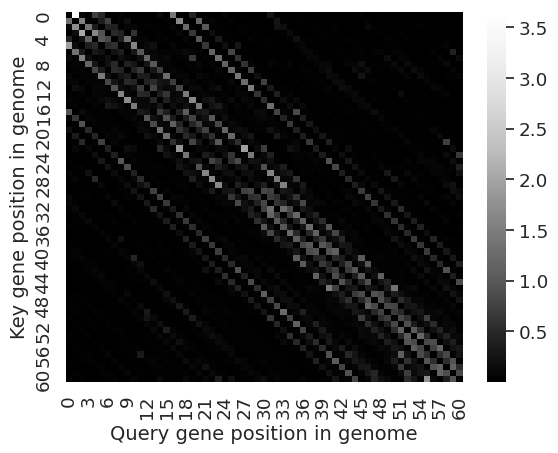

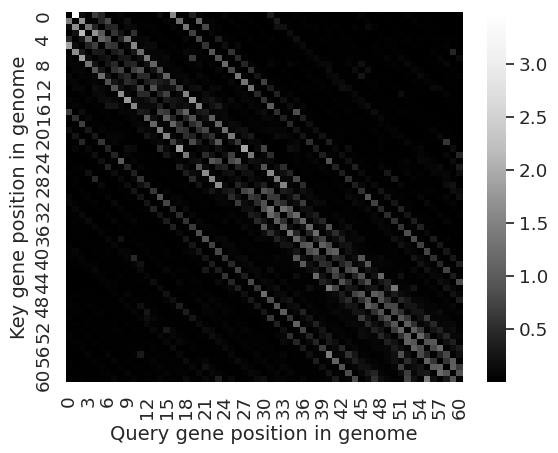

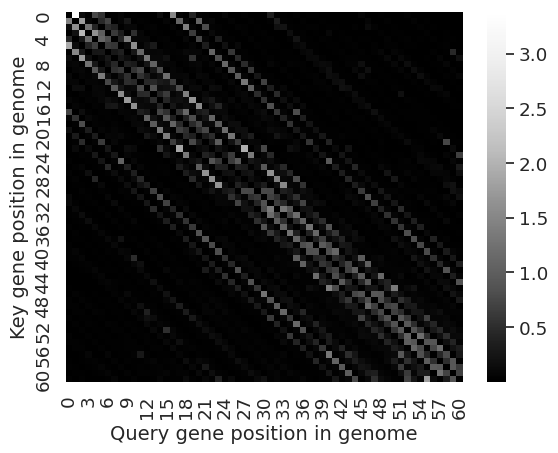

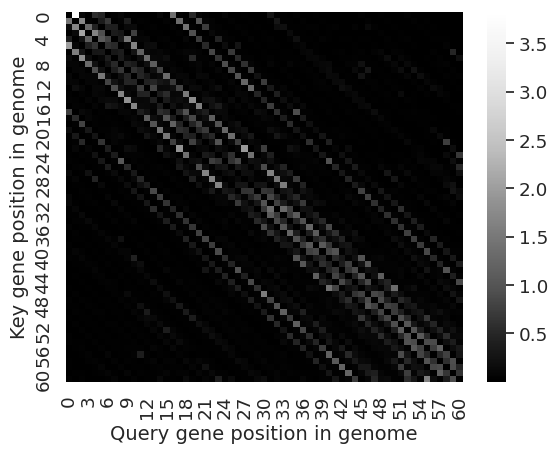

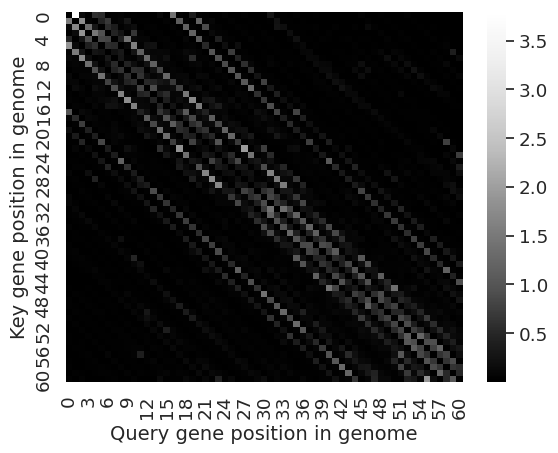

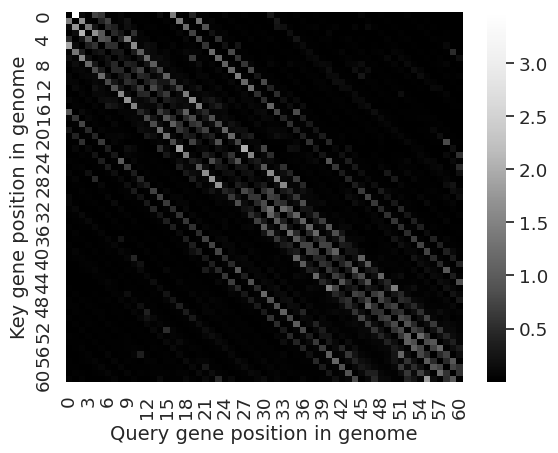

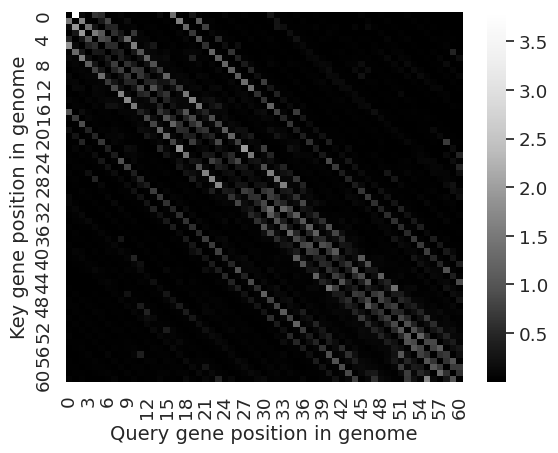

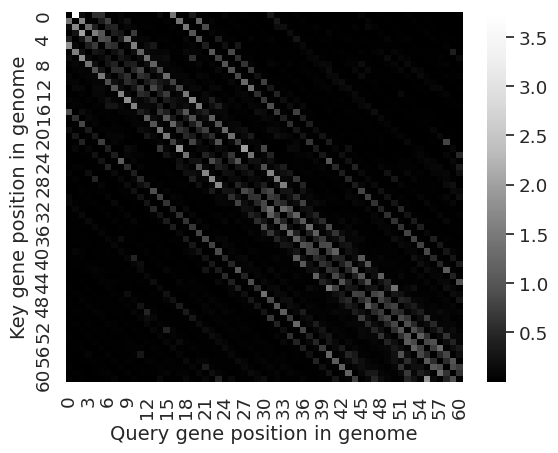

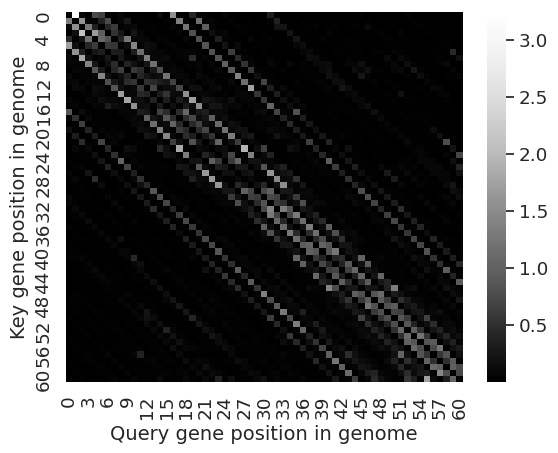

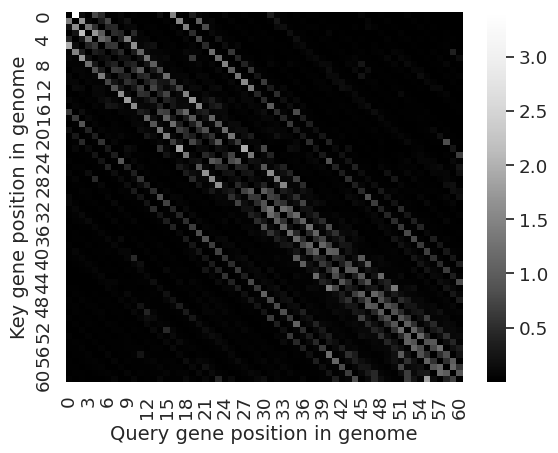

In [460]:
# this shows results of each model 
for i in range(0,10): 
    df = pd.DataFrame(attention_matrices[i].sum(axis=0))
    df = df.loc[(df != 0).any(axis=1), (df != 0).any(axis=0)]
    ax = sns.heatmap(df, cmap = 'Greys_r')
    # Remove tick labels
    #ax.set_xticks([])
    #ax.set_yticks([])

    # Label axes
    ax.set_xlabel("Query gene position in genome", fontsize=14)
    ax.set_ylabel("Key gene position in genome", fontsize=14)

    plt.show()

## Show attention between categories - show as a network 
How to visualise network with self loops - use the attention weight matrix 

In [90]:
pharokka_X = pickle.load(open('/home/grig0076/scratch/Phynteny_transformer/PhageScope/mergeddata_07012025/merged_data.X.pkl', 'rb'))
pharokka_y = pickle.load(open('/home/grig0076/scratch/Phynteny_transformer/PhageScope/mergeddata_07012025/merged_data.y.pkl', 'rb'))
phold_y = pickle.load(open('/home/grig0076/scratch/databases/PhageScope/pharokka_split_outputs/filtered_genbank/chunks/phold_data_balanced.y.pkl', 'rb'))

In [91]:
k = 1
batch_size=16
device='cpu'

# Load validation data and model
#val_labels = [line.strip() for line in open(f'/home/grig0076/GitHubs/Phynteny_transformer_15012025/Phynteny_transformer/phynteny_utils/models/noise_0.5_unshuffled_2025-3-21/val_kfold_keys/val_kfold_labels_fold{k+1}.txt').readlines()]
#val_labels = [line.strip() for line in open(f'/home/grig0076/scratch/Phynteny_transformer/models/2025-05-07/2025-4-24_16_0.15_circular_1e-5_0.1_512_8_2_0_10_0.0_0.6_false_True_true_true_1.0_0.7_sinusoidal/val_kfold_keys/val_kfold_labels_fold{k+1}.txt').readlines()] 
#val_labels = [line.strip() for line in open(f'/home/grig0076/scratch/Phynteny_transformer/models/2025-05-15_lambda/2025-05-20_16_0.15_circular_1e-5_0.1_512_8_2_100_10_0.0_0.6_false_True_true_true_1.0_0.3_sinusoidal/val_kfold_keys/val_kfold_labels_fold1.txt').readlines()]
val_labels = [line.strip() for line in open(f'/home/grig0076/scratch/Phynteny_transformer/models/2025-05-15_lambda/2025-05-07_16_0.15_circular_1e-5_0.1_512_8_2_100_10_0.0_0.6_false_True_true_true_1.0_0.7_sinusoidal/val_kfold_keys/val_kfold_labels_fold2.txt').readlines()]
                                            
val_labels = list(set(val_labels).intersection(phold_y.keys()))

validation_embeddings = [pharokka_X.get(v) for v in val_labels]
validation_categories = [pharokka_y.get(v) for v in val_labels]
validation_phold = [phold_y.get(v) for v in val_labels]

# create the object 
validation_dataset = model_onehot.EmbeddingDataset(validation_embeddings, validation_categories, val_labels, mask_portion=0)
validation_dataset.set_validation(validation_phold)

# set to a loader object 
validation_loader = DataLoader(validation_dataset, batch_size=batch_size, collate_fn=model_onehot.collate_fn) 
    
# read in the model 
p = predictor.Predictor(device=device)
#m = p.read_model(f'/home/grig0076/scratch/Phynteny_transformer/models/2025-05-15_lambda/2025-05-20_16_0.15_circular_1e-5_0.1_512_8_2_100_10_0.0_0.6_false_True_true_true_1.0_0.3_sinusoidal/fold_1transformer.model',
#            input_dim=1280,
#            num_classes=9,
#            num_heads=8,
#            hidden_dim=512,
#            lstm_hidden_dim=512,
#            dropout=0.1,
#            use_lstm=True,
#            max_len=1500) 

m = p.read_model(f'/home/grig0076/scratch/Phynteny_transformer/models/2025-05-15_lambda/2025-05-07_16_0.15_circular_1e-5_0.1_512_8_2_100_10_0.0_0.6_false_True_true_true_1.0_0.7_sinusoidal/fold_2transformer.model',
            input_dim=1280,
            num_classes=9,
            num_heads=8,
            hidden_dim=512,
            lstm_hidden_dim=512,
            dropout=0.1,
            use_lstm=True,
            max_len=1500) 

m.eval()
print("Model and validation data read")

2025-06-03 17:10:25.773 | INFO     | src.model_onehot:__init__:67 - Computed class weights: tensor([0.1841, 0.1473, 0.0347, 0.0284, 0.1228, 0.2231, 0.0871, 0.0456, 0.1270])
2025-06-03 17:10:25.775 | INFO     | src.model_onehot:__init__:68 - noise_std: 0
/home/grig0076/GitHubs/Phynteny_transformer_15012025/Phynteny_transformer/src/predictor.py:528: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_

Model and validation data read


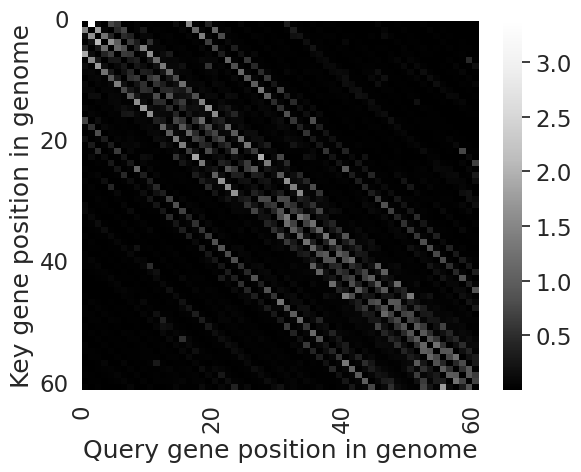

In [407]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

i = 2
sns.set(font_scale=1.5)

# Prepare DataFrame
df = pd.DataFrame(attention_matrices[i].sum(axis=0))
df = df.loc[(df != 0).any(axis=1), (df != 0).any(axis=0)]
AB823818_categories =AB823818_categories = corresponding_categories[corresponding_categories['phage'] == 'AB823818']['phrog_category'].to_list()


# Create heatmap
ax = sns.heatmap(df, cmap='Greys_r')

# Set axis labels
ax.set_ylabel('Key gene position in genome')
ax.set_xlabel('Query gene position in genome')

# Set tick marks at intervals of 20
xticks = list(range(0, df.shape[1], 20))
yticks = list(range(0, df.shape[0], 20))
ax.set_xticks(xticks)
ax.set_xticklabels(xticks, rotation=90)
ax.set_yticks(yticks)
ax.set_yticklabels(yticks, rotation=0)
plt.savefig('/home/grig0076/GitHubs/Phynteny_transformer/notebooks/manuscript_figures/attention_single_genome.png',  dpi=300, bbox_inches="tight")
plt.show()


/local/grig0076/2625771/ipykernel_4126066/3926895359.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space for colorbar


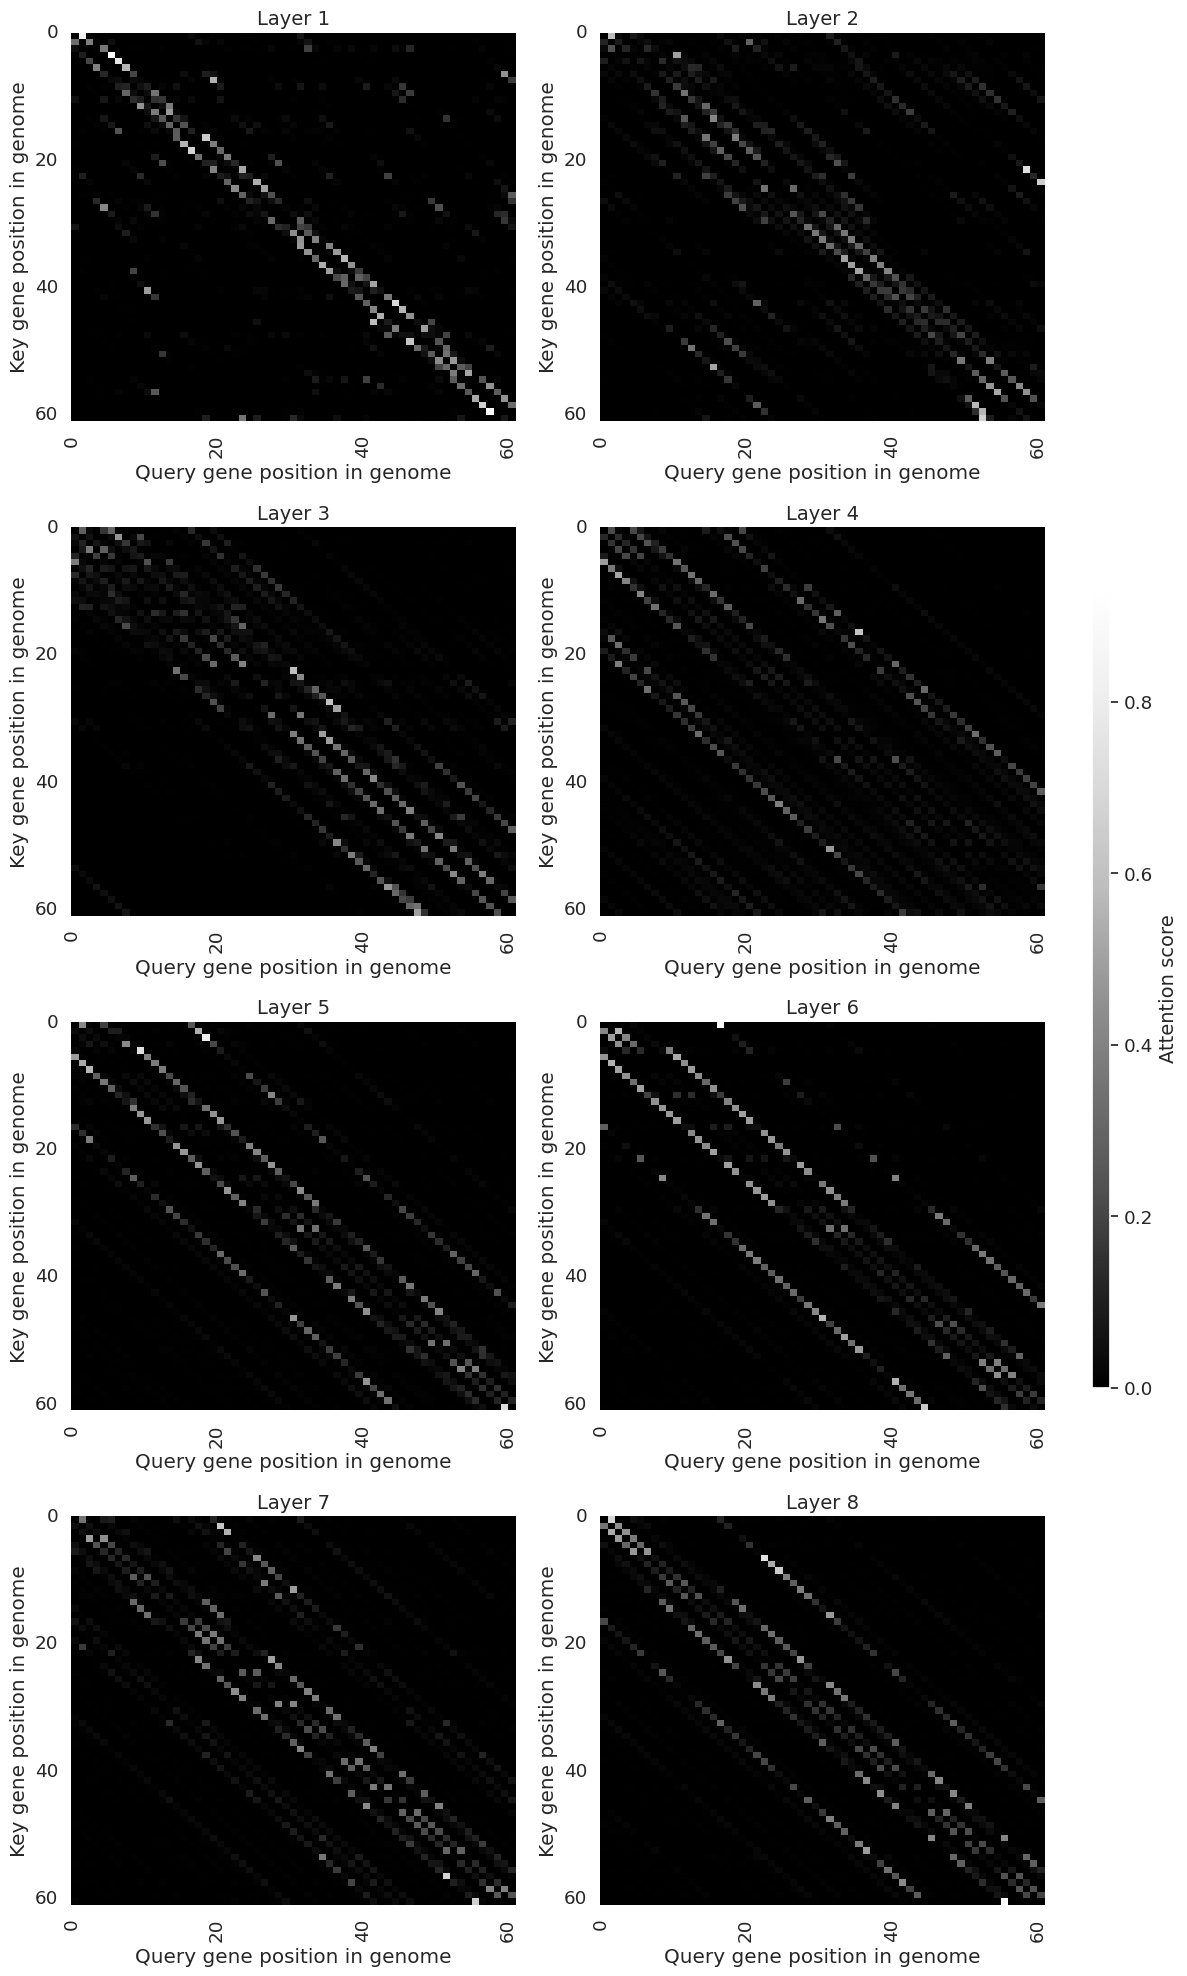

In [410]:
i = 2
sns.set(font_scale=1.2)

# Collect all 8 layers of attention for genome i
all_data = [pd.DataFrame(attention_matrices[i][layer]) for layer in range(8)]
all_data = [df.loc[(df != 0).any(axis=1), (df != 0).any(axis=0)] for df in all_data]

# Get global min/max for shared colorbar scaling
vmin = 0
vmax = max(df.max().max() for df in all_data)

# Set up 4×2 subplots
fig, axes = plt.subplots(4, 2, figsize=(12, 20))
axes = axes.flatten()

# Plot each attention layer
for layer in range(8):
    df_layer = all_data[layer]
    ax = axes[layer]

    sns.heatmap(
        df_layer,
        cmap='Greys_r',
        ax=ax,
        cbar=False,
        vmin=vmin,
        vmax=vmax
    )

    ax.set_title(f"Layer {layer + 1}", fontsize=14)
    ax.set_xlabel("Query gene position in genome")
    ax.set_ylabel("Key gene position in genome")

    # Add tick marks at intervals of 20
    xticks = list(range(0, df_layer.shape[1], 20))
    yticks = list(range(0, df_layer.shape[0], 20))
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticks, rotation=90)
    ax.set_yticks(yticks)
    ax.set_yticklabels(yticks, rotation=0)

# Remove unused axes (if any)
for j in range(len(attention_matrices[i]), len(axes)):
    fig.delaxes(axes[j])

# Add shared colorbar
cbar_ax = fig.add_axes([0.92, 0.3, 0.015, 0.4])  # [left, bottom, width, height]
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
sm = mpl.cm.ScalarMappable(cmap='Greys_r', norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar_ax.set_ylabel('Attention score', fontsize=14)

# Adjust layout and save
plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space for colorbar
plt.savefig(
    '/home/grig0076/GitHubs/Phynteny_transformer/notebooks/manuscript_figures/attention_all_layers.png',
    dpi=300, bbox_inches="tight"
)
plt.show()


In [92]:
import numpy as np
#multiprocessing_contextimport scipy.stats as stats

# Initialize category attentiocat_iatrix
num_categories = 9
category_attention = np.zeros((num_categories, num_categories))

batch_count = 0 

# Iterate over validation set
for embeddings, categories, masks, idx in validation_loader:
    batch_size = embeddings.shape[0]
    #print(batch_size)
    
    #print(batch_count)

    # Send tensors to device
    embeddings, categories, masks = (
        embeddings.to(device).float(),
        categories.to(device).long(),
        masks.to(device).float(),
    )

    # Compute mask
    src_key_padding_mask = (masks != -2).to(device)  # Mask for valid positions

    # Forward pass with attention weights
    outputs, attn = m(embeddings, src_key_padding_mask=src_key_padding_mask, return_attn_weights=True)
    
    # attn shape: (batch_size, num_heads, seq_len, seq_len)
    attn = attn.detach().cpu().numpy()  # Convert to numpy

    # Loop through batch
    for b in range(batch_size):
        selected_idx = idx[b].cpu().numpy()  # Convert tensor to numpy array
        selected_cats = categories[b, selected_idx].cpu().numpy()  # Get categories at selected indices

        # Compute mean attention over heads
        mean_attn = attn[b].mean(axis=0)  # Shape: (seq_len, seq_len)

        # Extract only relevant rows and columns
        mean_attn = mean_attn[selected_idx][:, selected_idx]

        # Populate category-category attention matrix
        for i, cat_i in enumerate(selected_cats):
            for j, cat_j in enumerate(selected_cats):
                category_attention[cat_i, cat_j] += mean_attn[i, j]
    
    batch_count +=1
    if batch_count % 100 == 0: 
        print(f"Processing batch:{batch_count}")
        
# Normalize by row sums to get relative attention
category_attention /= np.sum(category_attention, axis=1, keepdims=True)

# Compute correlation matrix between categories
category_correlation = np.corrcoef(category_attention)

print("Category-Category Correlation Matrix:\n", category_correlation)


Processing batch:100
Processing batch:200
Processing batch:300
Processing batch:400
Processing batch:500
Processing batch:600
Processing batch:700
Processing batch:800
Processing batch:900
Processing batch:1000
Processing batch:1100
Processing batch:1200
Processing batch:1300
Processing batch:1400
Processing batch:1500
Processing batch:1600
Processing batch:1700
Processing batch:1800
Category-Category Correlation Matrix:
 [[ 1.         -0.57781439 -0.68718073  0.53541778 -0.63402042  0.28758791
   0.1570874  -0.68910468  0.65559918]
 [-0.57781439  1.          0.70780192 -0.78865243  0.29937012 -0.47866856
  -0.70511333  0.67026003 -0.60116825]
 [-0.68718073  0.70780192  1.         -0.75296661  0.5722204  -0.55878168
  -0.55318733  0.81310429 -0.73725008]
 [ 0.53541778 -0.78865243 -0.75296661  1.         -0.64409075  0.42978929
   0.67760732 -0.81732555  0.62976177]
 [-0.63402042  0.29937012  0.5722204  -0.64409075  1.         -0.37747941
  -0.22130597  0.64098076 -0.713387  ]
 [ 0.2875

In [93]:
category_correlation_df = pd.DataFrame(category_correlation)
category_attention_df = pd.DataFrame(category_attention)

In [94]:
# save the category correlations to dataframe so that can be looked at later 
category_correlation_df.to_csv('category_correlation.csv')
category_attention_df.to_csv('category_attention.csv')

In [95]:
category_correlation_df = pd.read_csv('category_correlation.csv', index_col=0)
category_correlation = np.array(category_correlation_df)

/home/grig0076/miniconda3/envs/phynteny_transformer2/lib/python3.12/site-packages/seaborn/matrix.py:1113: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(**tight_params)


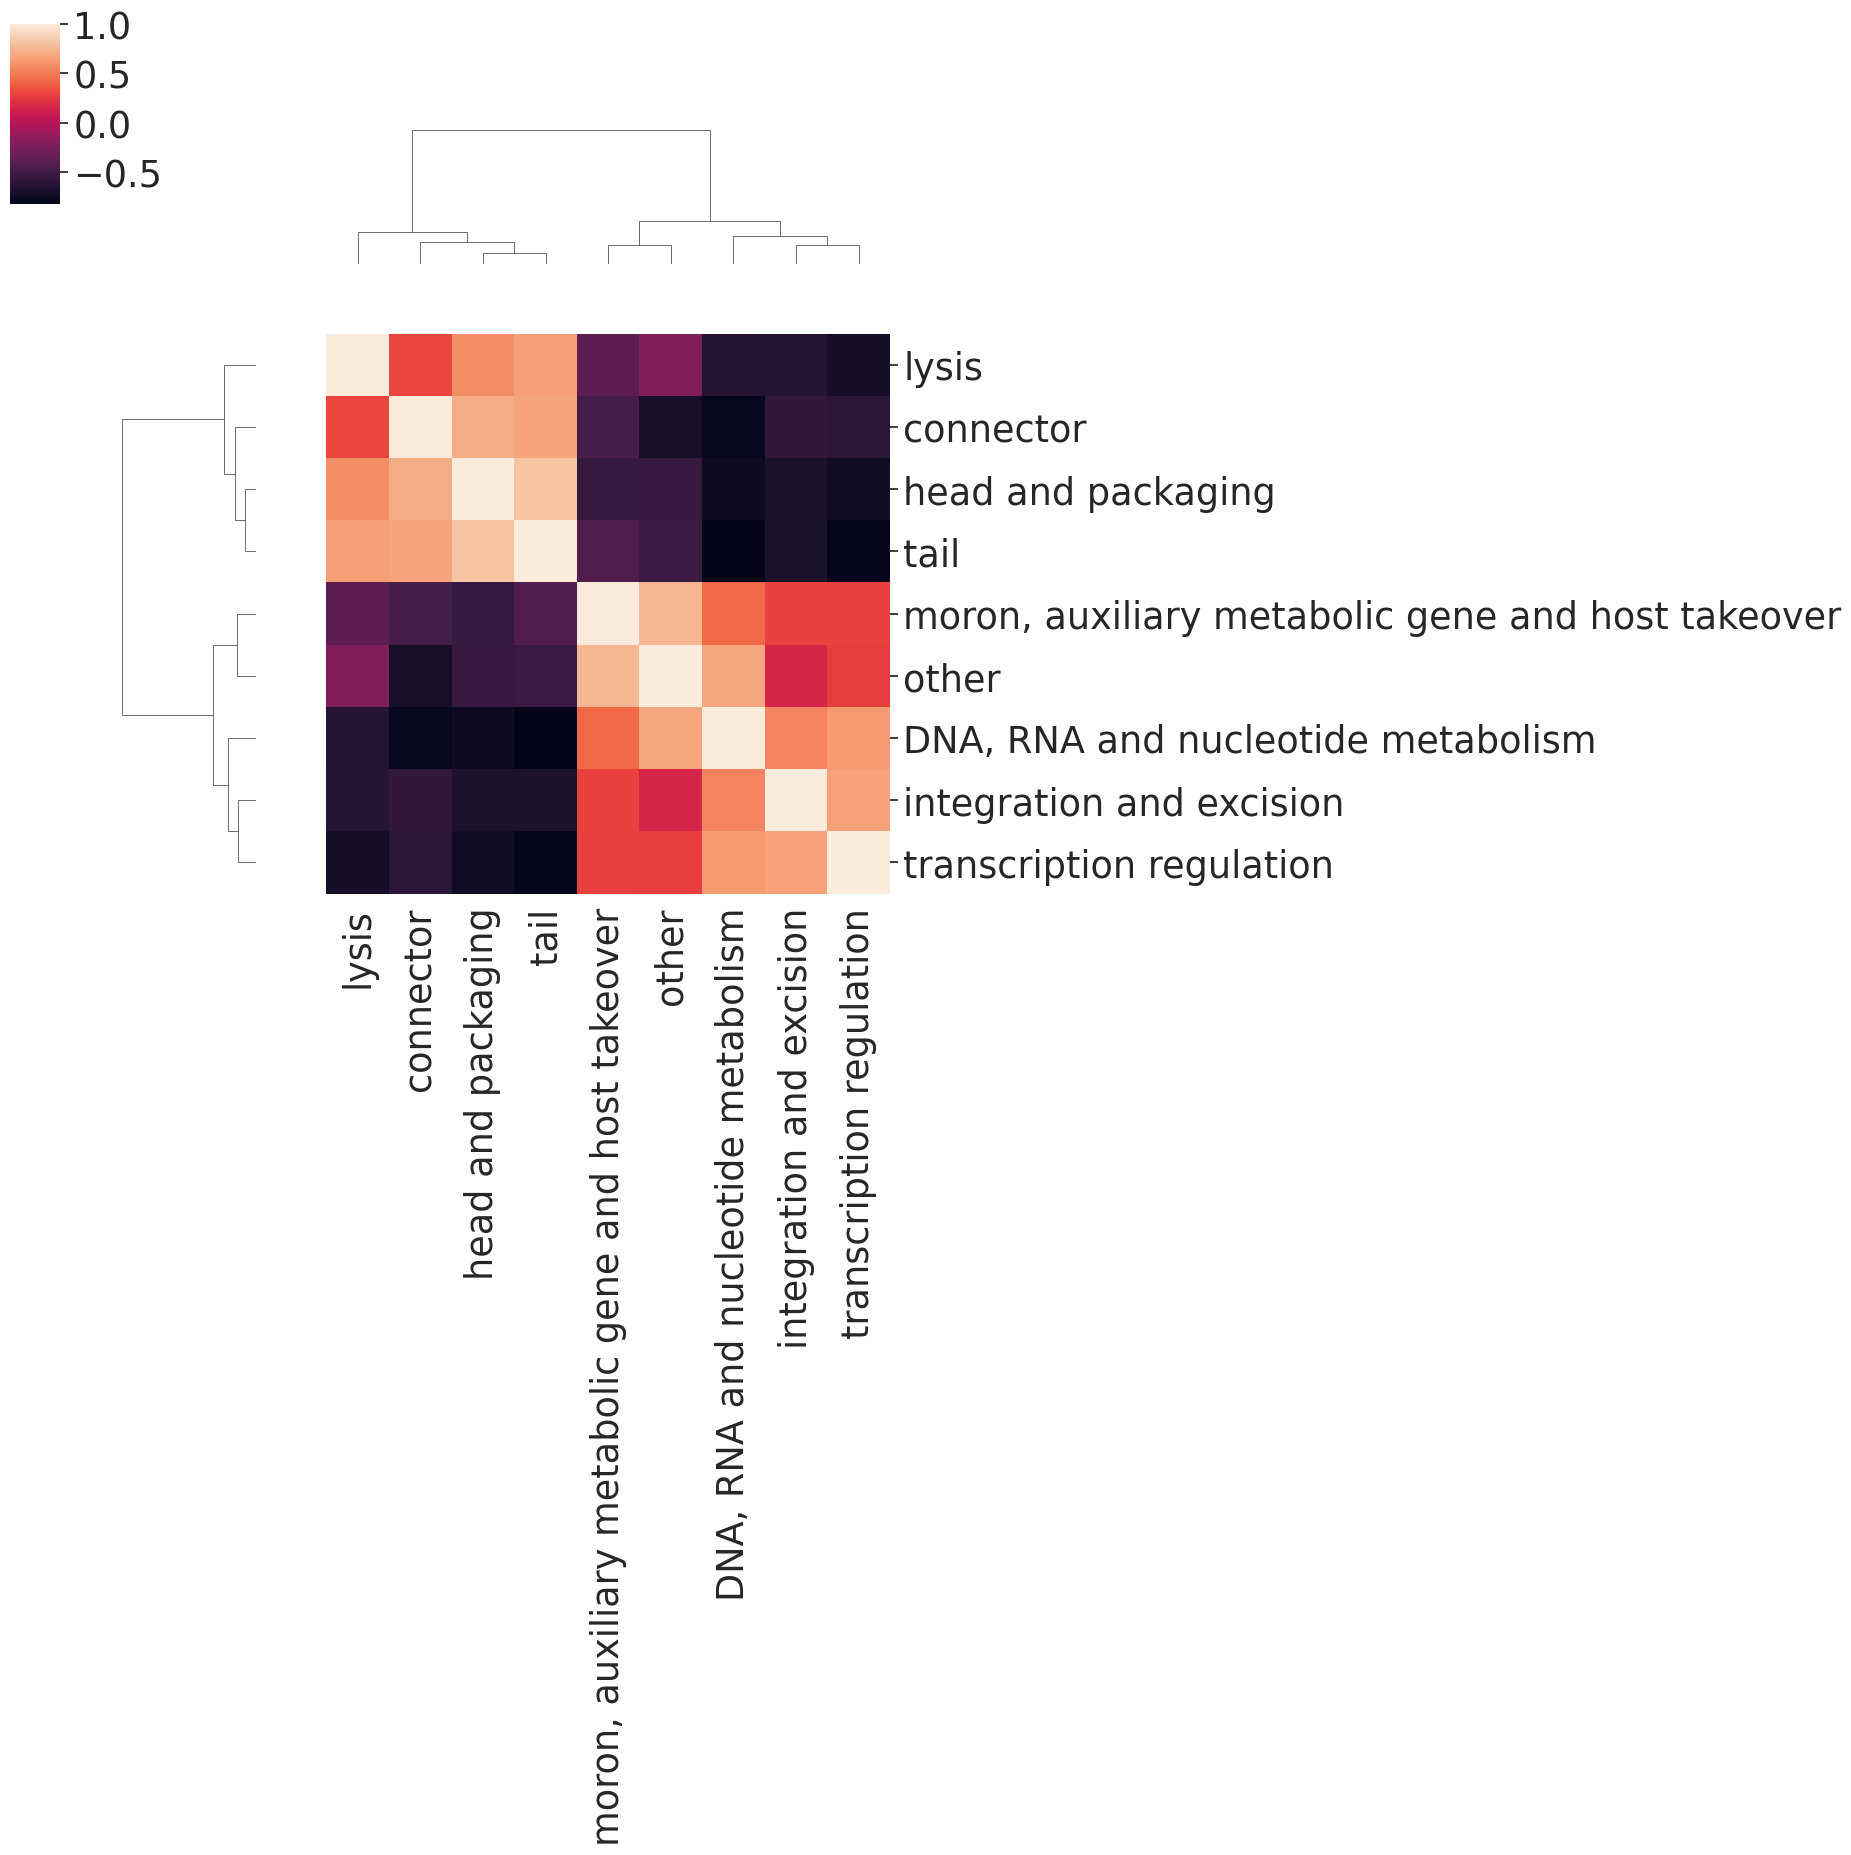

In [96]:
plot_category_correlation_df = category_correlation_df
plot_category_correlation_df.index = [phrog_integer.get(i)  for i in range(9)] 
plot_category_correlation_df.columns = [phrog_integer.get(i)  for i in range(9)] 
sns.clustermap(plot_category_correlation_df)
plt.savefig("/home/grig0076/GitHubs/Phynteny_transformer/notebooks/manuscript_figures/category_correlation_clustermap.png", dpi=300, bbox_inches="tight")

In [97]:
# put extra fig in supp info and then the one below as an actual figure 

In [128]:
phrog_integer = {3: 'nucleic acid metabolism',
 1: 'connector',
 2: 'head and packaging',
 0: 'integration and excision',
 4: 'lysis',
 5: 'morons',
 6: 'other',
 7: 'tail',
 8: 'transcription regulation',
 -1: 'unknown function'}
colors1=  [ '#CC6677','#DDCC77', '#332288',  '#117733', '#88CCEE',
                    '#882255', '#44AA99',  '#AA4499', '#999933'] # can be accessed from  


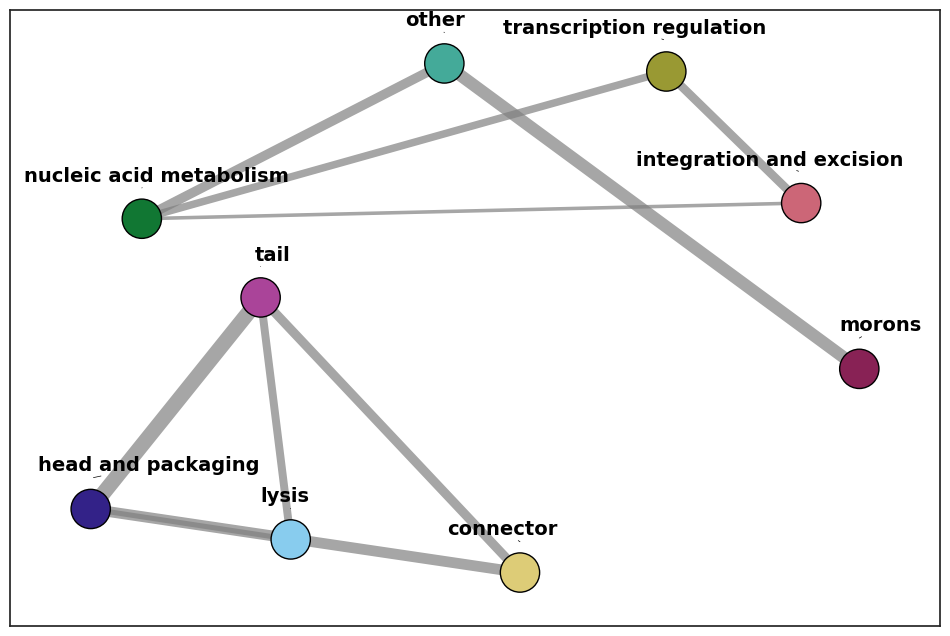

In [133]:
import networkx as nx
import matplotlib.pyplot as plt
from adjustText import adjust_text  # Install with: pip install adjustText

# Define threshold for showing edges
threshold = 0.5


# Create a graph
G = nx.Graph()

# Add nodes (categories) with labels
num_categories = category_correlation.shape[0]
for i in range(num_categories):
    G.add_node(i, label=phrog_integer.get(i , f"Category {i }"))  # Default to "Category {i+1}" if missing

# Add edges where correlation > threshold
for i in range(num_categories):
    for j in range(i + 1, num_categories):  # Avoid duplicate edges
        if category_correlation[i, j] > threshold:
            G.add_edge(i, j, weight=category_correlation[i, j])

# Use Spring layout with higher k-value for more spread
pos = nx.spring_layout(G, k=2)

# Assign colors based on node index (cyclic if more than 10 categories)
node_colors = [colors1[i % len(colors1)] for i in range(num_categories)]

# Draw the graph
plt.figure(figsize=(12, 8))
edges = G.edges(data=True)

# Draw nodes with assigned colors
nx.draw_networkx_nodes(G, pos, node_size=800, node_color=node_colors, edgecolors="black")


nx.draw_networkx_edges(
    G, pos, 
    edgelist=[(u, v) for u, v, w in edges], 
    width=[max((w['weight'] - 0.45) * 30, 1.5) for u, v, w in edges],  # min width = 1.5
    alpha=0.7, edge_color="gray"
)

# Create a dictionary mapping integer categories to their PHROG names
labels = {i: phrog_integer.get(i , f"Category {i}") for i in range(num_categories)}

# Store text objects to adjust later
texts = []

# Plot labels with further offsets and increased font size
for node, (x, y) in pos.items():
    label = labels[node]
    text = plt.text(x, y + 0.12, label, fontsize=14, fontweight="bold", ha="center", color="black")
    texts.append(text)

# Adjust label positions to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle="-", color='black', lw=0.5))
plt.savefig('/home/grig0076/scratch/Phynteny_transformer/attention_weights_network.png')
plt.show()
